In [53]:
import matplotlib.pyplot as plt
import matplotlib.animation as animation
import pandas as pd

In [54]:
df = pd.read_csv("countries.csv", index_col="index")
df = df.sort_values("populatie")
df

,tara,populatie
index,,
10,Mexico,126
9,Russia,146
8,Bangladesh,170
7,Nigeria,211
6,Brazil,213
5,Pakistan,225
4,Indonesia,271
3,United States,331
2,India,1378


In [55]:
countries = list(df.tara)
population = list(df.populatie)

In [56]:
len(countries)

10

In [57]:
# countries.iloc[0], population.iloc[0]

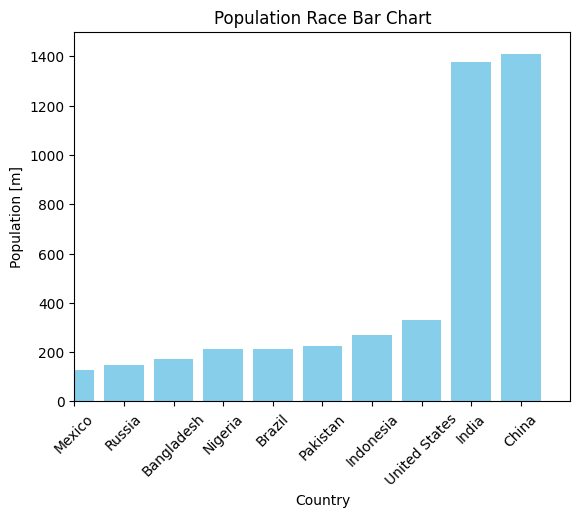

In [58]:
fig, ax = plt.subplots()

bar_plot = ax.bar(countries[0], population[0])
bar_plot.datavalues


ax.set(xlim=[0, 10], ylim=[0, 1500], xlabel='Country [s]', ylabel='Population [m]')

def update(frame):
    # x = countries[:frame]
    # y = population[:frame]
    # print("x=", x)
    # print("y=", y)
    # bar_plot.set_x(x)
    # bar_plot.set_height(y)
    # return (x, y)

    ax.clear()
    ax.set_xlim(0, 10)
    ax.set_ylim(0, 1500)
    ax.set_xlabel('Country')
    ax.set_ylabel('Population [m]')
    ax.set_title('Population Race Bar Chart')

    # Afișează doar primele `frame` țări
    current_countries = countries[:frame+1]
    current_population = population[:frame+1]

    # Creează barele pentru țările curente
    bars = ax.bar(range(len(current_countries)), current_population, color='skyblue')
    ax.set_xticks(range(len(current_countries)))
    ax.set_xticklabels(current_countries, rotation=45)

    return bars


ani = animation.FuncAnimation(fig=fig, func=update, repeat=False, frames=len(countries), interval=300);
ani.save("test.mp4")
plt.show()

In [3]:
import matplotlib.pyplot as plt
import matplotlib.animation as animation
import pandas as pd

from IPython.display import HTML

# Datele tale
data = {
    'tara': ['China', 'India', 'United States', 'Indonesia', 'Pakistan', 'Brazil', 'Nigeria', 'Bangladesh', 'Russia', 'Mexico'],
    'populatie': [1411, 1378, 331, 271, 225, 213, 211, 170, 146, 126]
}
df = pd.DataFrame(data)
countries = df['tara'].values
population = df['populatie'].values

fig, ax = plt.subplots(figsize=(10, 6))
ax.set_xlim(0, 10)
ax.set_ylim(0, 1500)
ax.set_xlabel('Country')
ax.set_ylabel('Population [m]')
ax.set_title('Population Race Bar Chart')

# Creează barele inițiale (goale)
bars = ax.bar([], [], color='skyblue')

def update(frame):
    ax.clear()
    ax.set_xlim(0, 10)
    ax.set_ylim(0, 1500)
    ax.set_xlabel('Country')
    ax.set_ylabel('Population [m]')
    ax.set_title('Population Race Bar Chart')

    # Afișează doar primele `frame` țări
    current_countries = countries[:frame+1]
    current_population = population[:frame+1]

    # Creează barele pentru țările curente
    bars = ax.bar(range(len(current_countries)), current_population, color='skyblue')
    ax.set_xticks(range(len(current_countries)))
    ax.set_xticklabels(current_countries, rotation=45)

    return bars

ani = animation.FuncAnimation(
    fig=fig,
    func=update,
    frames=len(countries),
    interval=500,
    repeat=False
)

plt.close()
HTML(ani.to_jshtml())

/Library/Frameworks/Python.framework/Versions/3.14/lib/python3.14/site-packages/matplotlib/animation.py:908: UserWarning: Animation was deleted without rendering anything. This is most likely not intended. To prevent deletion, assign the Animation to a variable, e.g. `anim`, that exists until you output the Animation using `plt.show()` or `anim.save()`.
  warnings.warn(


In [7]:
data = {
    'tara': ['China', 'India', 'United States', 'Indonesia', 'Pakistan', 'Brazil', 'Nigeria', 'Bangladesh', 'Russia', 'Mexico'],
    'populatie': [1411, 1378, 331, 271, 225, 213, 211, 170, 146, 126]
}

populations_by_size = {
   population : { 'tara' : data['tara'], 'populatie' : [ population if population < p else p for p in data['populatie'] ] } for population in reversed(data['populatie'])
}
layers = sorted(populations_by_size.keys())
layers

[126, 146, 170, 211, 213, 225, 271, 331, 1378, 1411]

In [10]:
population_dict = populations_by_size[126] 
population_dict

{'tara': ['China',
  'India',
  'United States',
  'Indonesia',
  'Pakistan',
  'Brazil',
  'Nigeria',
  'Bangladesh',
  'Russia',
  'Mexico'],
 'populatie': [126, 126, 126, 126, 126, 126, 126, 126, 126, 126]}

In [13]:
import matplotlib.pyplot as plt
import matplotlib.animation as animation
import pandas as pd

from IPython.display import HTML

# Datele tale
data = {
    'tara': ['China', 'India', 'United States', 'Indonesia', 'Pakistan', 'Brazil', 'Nigeria', 'Bangladesh', 'Russia', 'Mexico'],
    'populatie': [1411, 1378, 331, 271, 225, 213, 211, 170, 146, 126]
}

populations_by_size = {
   population : { 'tara' : data['tara'], 'populatie' : [ population if population < p else p for p in data['populatie'] ] } for population in reversed(data['populatie'])
}


layers = sorted(populations_by_size.keys())

df = pd.DataFrame(data)
countries = df['tara'].values
population = df['populatie'].values

fig, ax = plt.subplots(figsize=(10, 6))
ax.set_xlim(0, 10)
ax.set_ylim(0, 1500)
ax.set_xlabel('Country')
ax.set_ylabel('Population [m]')
ax.set_title('Population Race Bar Chart')

# Creează barele inițiale (goale)
bars = ax.bar([], [], color='skyblue')




def update(layer):
    ax.clear()
    ax.set_xlim(0, 10)
    ax.set_ylim(0, 1500)
    ax.set_xlabel('Country')
    ax.set_ylabel('Population [m]')
    ax.set_title('Population Race Bar Chart')


    population_dict = populations_by_size[layer] 

    # Afișează doar primele `frame` țări
    current_countries = population_dict["tara"]
    current_population =  population_dict["populatie"]

    # Creează barele pentru țările curente
    bars = ax.bar(range(len(current_countries)), current_population, color='skyblue')
    ax.set_xticks(range(len(current_countries)))
    ax.set_xticklabels(current_countries, rotation=45)

    return bars

ani = animation.FuncAnimation(
    fig=fig,
    func=update,
    frames=layers,
    interval=500,
    repeat=True
)

plt.close()
HTML(ani.to_jshtml())